## Assignment 1: Data Analysis and Machine Learning

### Ky Cuong Pham a1906313

#### How can we use data analytics and Machine Learning to predict energy usage for this house?

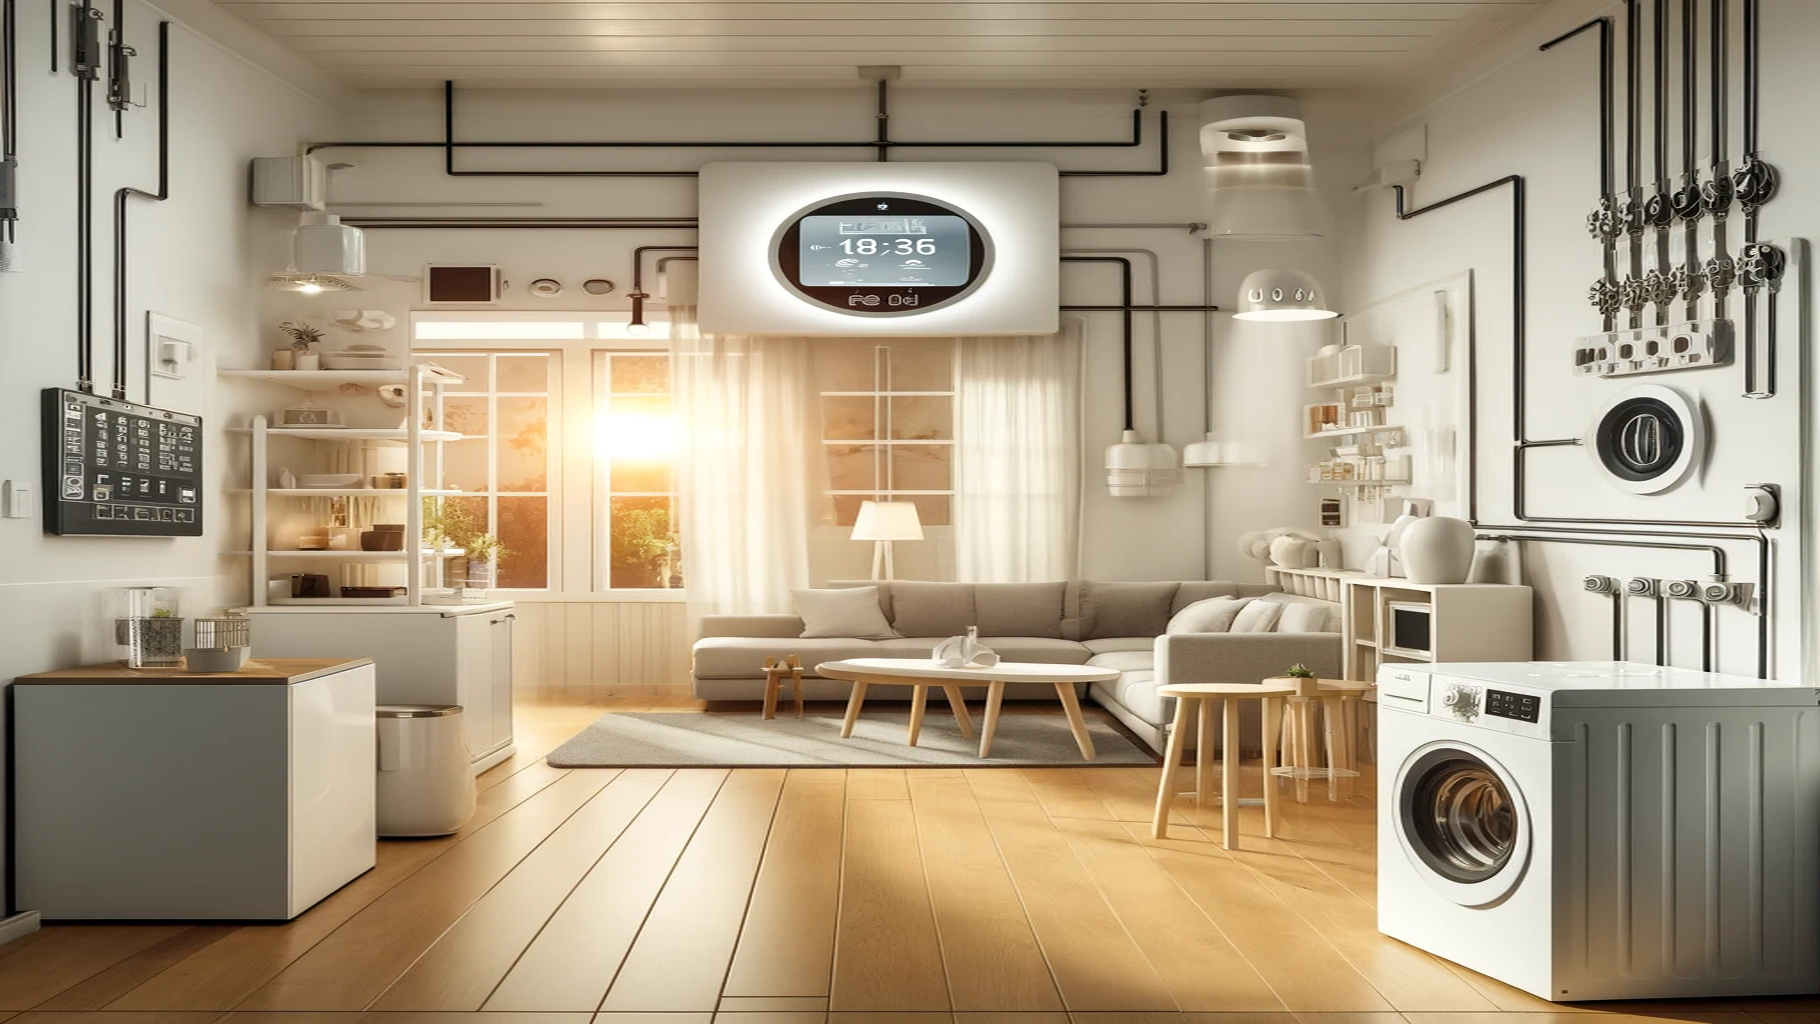

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

In [3]:
# seed the random numbers for reproducibility 
# do not remove this line
import random 
random.seed(10)

### 1. Analyse and visualise the data

#### 1.1. Read the dataset

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

orginal_df = pd.read_csv('energydata_complete.csv')
orginal_df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,14/02/2016 0:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,...,18.0,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978
1,14/02/2016 0:10,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,...,18.0,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359
2,14/02/2016 0:20,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,...,18.0,42.360000,2.83,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115
3,14/02/2016 0:30,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,...,18.0,42.633333,2.80,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509
4,14/02/2016 0:40,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,...,18.0,42.860000,2.77,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574


In [2]:
orginal_df.shape

(14941, 29)

In [3]:
#Keep the original df isolated
df = orginal_df.copy()
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.head()

/tmp/ipykernel_5311/3931192104.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,41.00,...,18.0,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,41.06,...,18.0,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,41.09,...,18.0,42.360000,2.83,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,41.09,...,18.0,42.633333,2.80,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,41.09,...,18.0,42.860000,2.77,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574


In [4]:
# date time year-month-day hour:minute:second 
# Appliances, energy use in Wh
# lights, energy use of light fixtures in the house in Wh
# T1, Temperature in kitchen area, in Celsius
# RH_1, Humidity in kitchen area, in %
# T2, Temperature in living room area, in Celsius
# RH_2, Humidity in living room area, in %
# T3, Temperature in laundry room area
# RH_3, Humidity in laundry room area, in %
# T4, Temperature in office room, in Celsius
# RH_4, Humidity in office room, in %
# T5, Temperature in bathroom, in Celsius
# RH_5, Humidity in bathroom, in %
# T6, Temperature outside the building (north side), in Celsius
# RH_6, Humidity outside the building (north side), in %
# T7, Temperature in ironing room , in Celsius
# RH_7, Humidity in ironing room, in %
# T8, Temperature in teenager room 2, in Celsius
# RH_8, Humidity in teenager room 2, in %
# T9, Temperature in parents room, in Celsius
# RH_9, Humidity in parents room, in %
# To_out, Temperature outside (from Chievres weather station), in Celsius
# Press_mg_hg, Pressure (from Chievres weather station), in mm Hg
# RH_out, Humidity outside (from Chievres weather station), in %
# Wind speed (from Chievres weather station), in m/s
# Visibility (from Chievres weather station), in km
# Tdewpoint (from Chievres weather station), Â°C
# rv1, Random variable 1, nondimensional
# rv2, Random variable 2, nondimensional

# !!!rv1 and rv2 are just for testing the robustness of the model, it should not rely on these variables
# the model should be able to predict the energy use without these variables
print(f"Shape of the df: {df.shape}")
print(f"Columns in the df: {df.columns}")

Shape of the df: (14941, 28)
Columns in the df: Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')


#### 1.2. Analyse data characteristics

In [5]:
df.describe()
# lights seems unneccessary

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,...,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,96.747206,3.235393,22.030776,39.418672,20.519140,39.935868,22.770465,38.046386,21.425985,37.701517,...,20.143157,40.454742,8.182569,755.575393,77.559434,3.671039,37.922696,4.055227,25.047636,25.047636
std,97.297111,7.296554,1.469766,3.880367,2.322643,4.328421,1.897689,2.530175,1.843571,3.701348,...,1.782497,3.566295,5.464633,6.613943,15.720014,2.218070,11.415145,4.220123,14.436670,14.436670
min,10.000000,0.000000,18.600000,27.023333,16.200000,20.463333,19.100000,28.766667,17.290000,27.660000,...,17.260000,29.166667,-4.400000,732.900000,24.000000,0.000000,1.000000,-6.100000,0.005322,0.005322
25%,50.000000,0.000000,21.000000,36.790000,18.890000,37.260000,21.390000,36.363333,20.100000,34.900000,...,18.571429,38.030000,4.230000,751.200000,66.666667,2.000000,29.000000,0.983000,12.593007,12.593007
50%,60.000000,0.000000,21.823333,38.790000,20.000000,39.900000,22.566667,37.760000,21.166667,37.200000,...,20.000000,39.863333,7.630000,755.700000,80.833333,3.166667,40.000000,3.600000,25.120708,25.120708
75%,100.000000,0.000000,22.890000,41.400000,21.830000,42.700000,24.033333,39.260000,22.738571,39.700000,...,20.890000,42.530000,11.400000,760.200000,90.833333,5.000000,40.000000,6.900000,37.454428,37.454428
max,900.000000,50.000000,26.260000,57.496667,29.856667,56.026667,29.236000,47.693333,26.200000,50.760000,...,24.500000,51.536000,26.100000,772.300000,100.000000,13.000000,66.000000,15.500000,49.992758,49.992758


In [6]:
# Analyse data characteristics (dependencies, distributions, etc.) that may affect the prediction task, and visualise them using suitable techniques and charts. Include required charts, diagrams, tables and discussion in Jupyter Notebook.
# checking for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14941 entries, 2016-02-14 00:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   14941 non-null  int64  
 1   lights       14941 non-null  int64  
 2   T1           14941 non-null  float64
 3   RH_1         14941 non-null  float64
 4   T2           14941 non-null  float64
 5   RH_2         14941 non-null  float64
 6   T3           14941 non-null  float64
 7   RH_3         14941 non-null  float64
 8   T4           14941 non-null  float64
 9   RH_4         14941 non-null  float64
 10  T5           14941 non-null  float64
 11  RH_5         14941 non-null  float64
 12  T6           14941 non-null  float64
 13  RH_6         14941 non-null  float64
 14  T7           14941 non-null  float64
 15  RH_7         14941 non-null  float64
 16  T8           14941 non-null  float64
 17  RH_8         14941 non-null  float64
 18  T9         

In [7]:
# checking for missing values
df.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [8]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# df['month'] = df.index.month
# df['weekday'] = df.index.weekday
df['hour'] = df.index.hour
# df['day'] = df.index.day
# df['day_of_week'] = df.index.dayofweek
df.head(2)

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.79,39.9,20.100000,40.79,21.39,40.59,19.2,41.00,...,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978,0
2016-02-14 00:10:00,50,0,21.79,39.9,20.033333,40.73,21.39,40.59,19.2,41.06,...,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359,0


Text(0, 0.5, 'Energy Usage (Wh)')

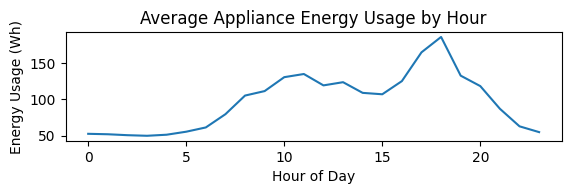

In [10]:
plt.subplot(3, 1, 1)
daily_energy = df.groupby('hour')['Appliances'].mean()
sns.lineplot(x=daily_energy.index, y=daily_energy.values)
plt.title('Average Appliance Energy Usage by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Energy Usage (Wh)')

In [11]:
# around 10 and dinner time 
# late night and morning are the lowest 
# => Useful

Text(0.5, 1.0, 'Average Indoor Temperature vs Energy Usage')

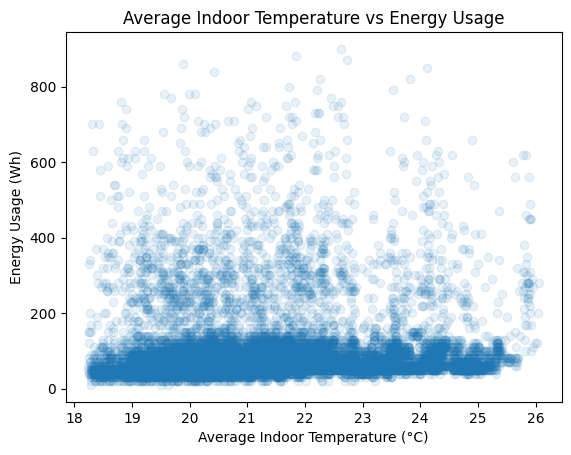

In [11]:
# avarage inside temp impact on energy usage
avg_indoor_temps = df[['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']].mean(axis=1)
plt.scatter(avg_indoor_temps, df['Appliances'], alpha=0.1)
plt.xlabel('Average Indoor Temperature (°C)')
plt.ylabel('Energy Usage (Wh)')
plt.title('Average Indoor Temperature vs Energy Usage')

In [18]:
#Does not show any obvious correlation

Text(0.5, 1.0, 'Indoor vs Outdoor Temperature')

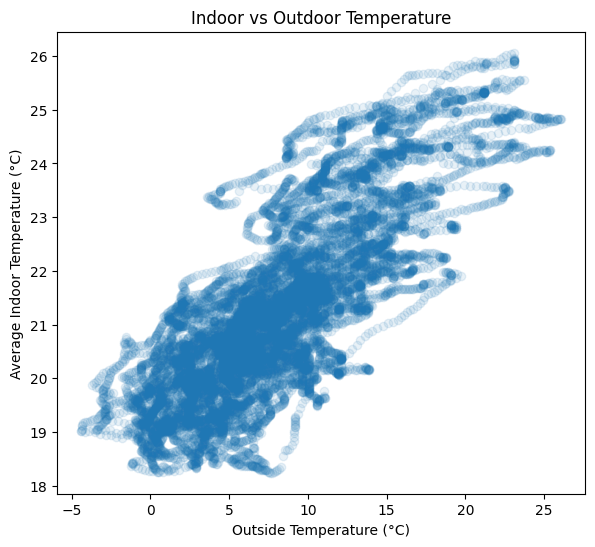

In [12]:
# indoor vs outdoor
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(df['T_out'], avg_indoor_temps, alpha=0.1)
plt.xlabel('Outside Temperature (°C)')
plt.ylabel('Average Indoor Temperature (°C)')
plt.title('Indoor vs Outdoor Temperature')

In [20]:
# indoor and outdoor might be correlated. Higher indoor mean higher outdoor

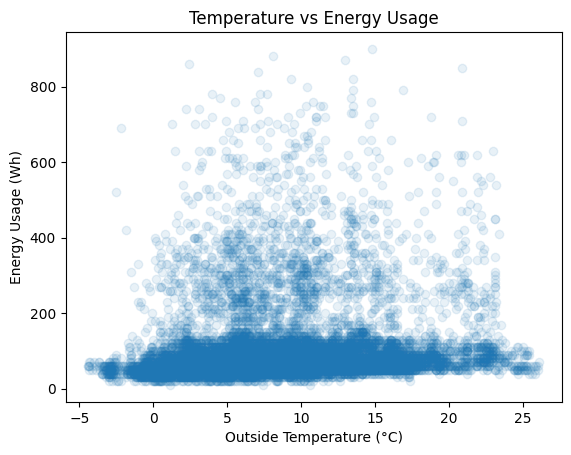

In [13]:

# Outside temp impact on energy usage
plt.scatter(df['T_out'], df['Appliances'], alpha=0.1)
plt.xlabel('Outside Temperature (°C)')
plt.ylabel('Energy Usage (Wh)')
plt.title('Temperature vs Energy Usage')
plt.show()

<Figure size 1200x600 with 0 Axes>

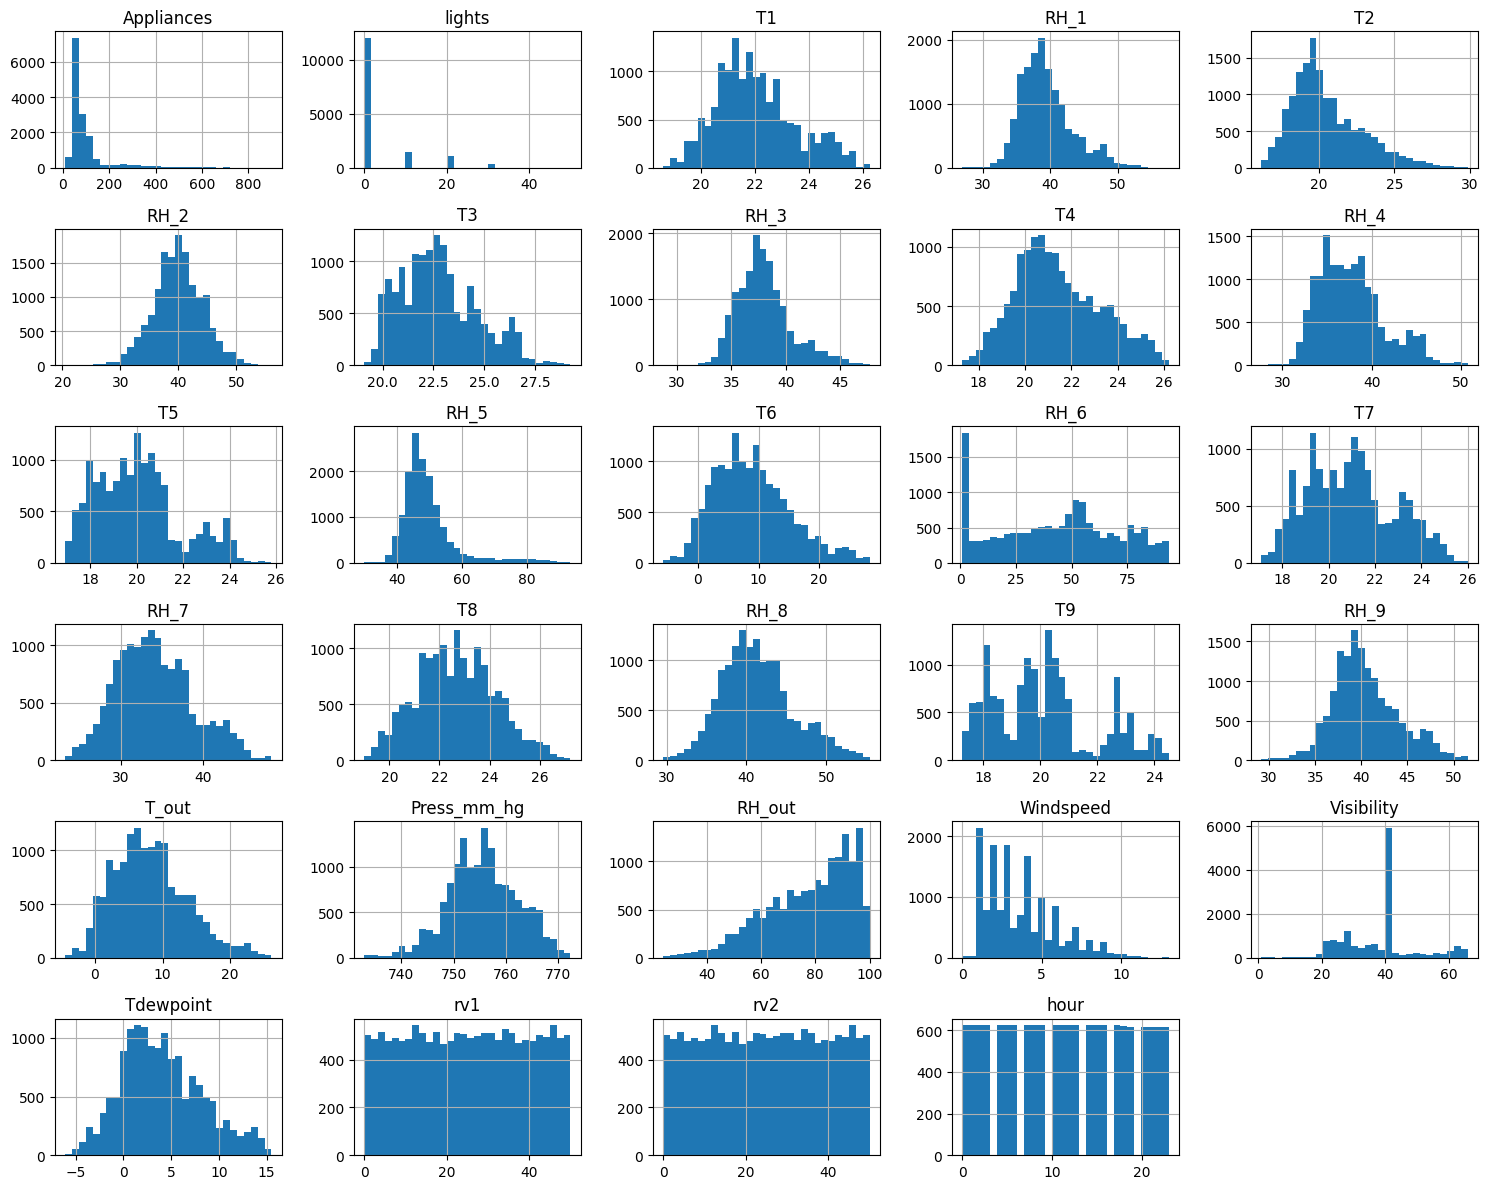

In [14]:
plt.figure(figsize=(12, 6))
df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [23]:
# some of them are normally distributed, some are not
# some implications for the model:
#1. statistical models assume normal distribution like linear regression might not work well
#2. can use log to normalize the data
#3. Outliers
#4. Need data understanding to decide which model to use
#5. Need to handle skewed data

In [27]:
#Friday, Saturday Sunday and Monday have higher energy usage, alot of outliers above 200

In [28]:
#does not show nay correlation => Temp might be useless

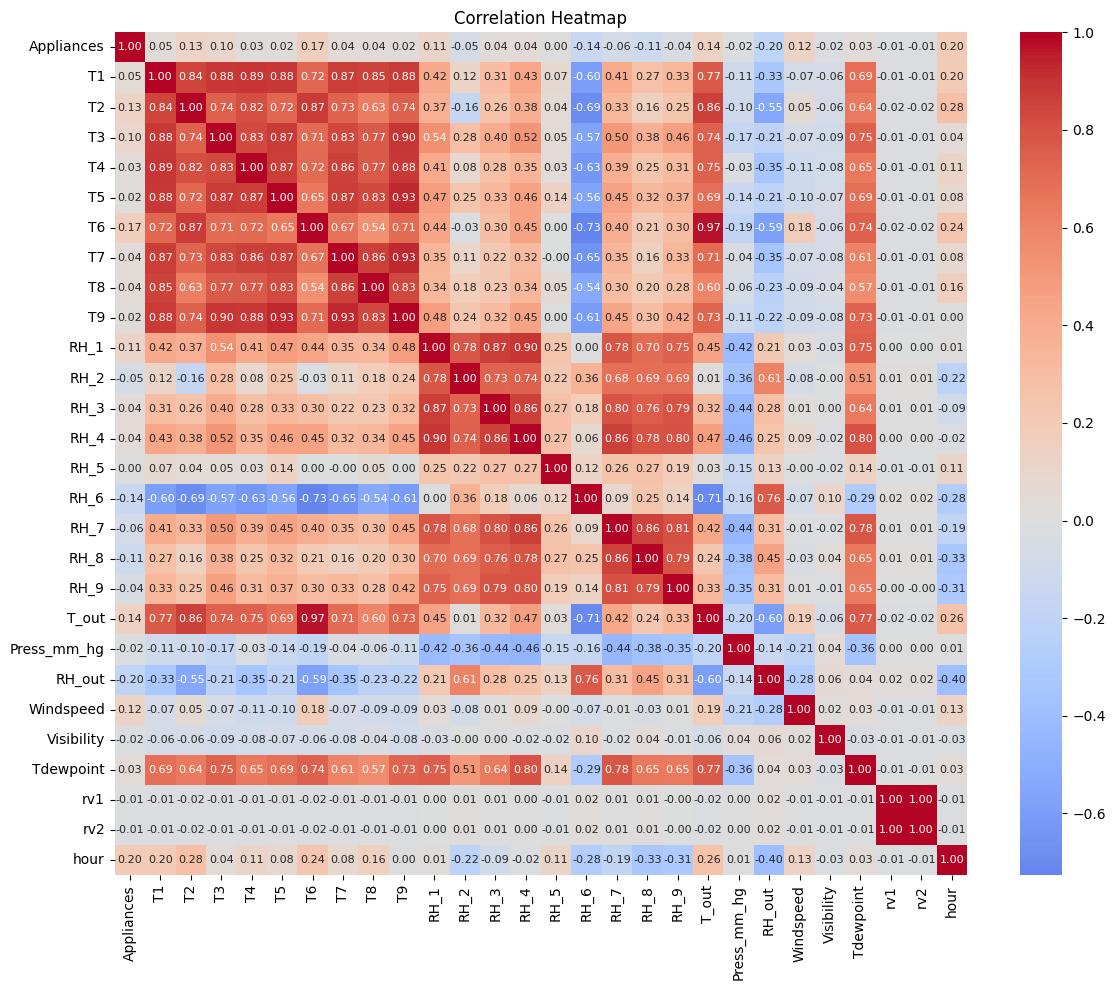

In [15]:
def analyze_correlations_heatmap(df):
    # Select relevant columns
    temp_cols = [f'T{i}' for i in range(1, 10)]
    humidity_cols = [f'RH_{i}' for i in range(1, 10)]
    weather_cols = ['T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']
    random_variable_cols = ['rv1', 'rv2']
    periods_cols = ['hour']
    
    # Calculate correlations
    cols_to_analyze = ['Appliances'] + temp_cols + humidity_cols + weather_cols + random_variable_cols + periods_cols
    corr_matrix = df[cols_to_analyze].corr()
    
    # Plot heatmap with correlation values
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f",
                xticklabels=True, yticklabels=True, annot_kws={"size": 8})
    
    # Customize appearance
    plt.title('Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix['Appliances'].sort_values(ascending=False)

corr = analyze_correlations_heatmap(df)


In [30]:
# appliance are not strongly correlated with any of the features, indicating non-linear relationship -> need to use non-linear models

In [31]:
# indoor and outdoor doesnt matter that much 

In [32]:
# indoor_temps

In [33]:
# 3. Discuss the results of your analysis and visualisation. Make sure your charts are of good quality and useful, there is no point to make a chart or a table, if it is not referred to in your discussion. 


### 2. Pre-process the data

In [27]:
# plt.figure(figsize=(20, 15))
# plt.suptitle("Box Plot for Each Column", fontsize=18, y=0.95)

# # Plot box plots for each column in the dataframe
# for i, column in enumerate(df.columns):
#     plt.subplot(9, 4, i + 1)
#     sns.boxplot(x=df[column])
#     plt.title(column.upper())
#     plt.xlabel('')

# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

In [26]:
# df.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2', 'month', 'weekday', 'hour', 'day',
       'day_of_week', 'day_of_week_num'],
      dtype='object')

In [28]:
# # Handling Outliers & Outlier treatments
# import pandas as pd
# import numpy as np

# def find_outliers_iqr(data):
#     # Calculate the first quartile (Q1) and third quartile (Q3) for each column
#     q1 = data.quantile(0.25)
#     q3 = data.quantile(0.75)

#     # Calculate the interquartile range (IQR) for each column
#     iqr = q3 - q1

#     # Calculate the lower and upper bounds for outliers for each column
#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     # Check for outliers in each column and count the number of outliers
#     outliers_count = (data < lower_bound) | (data > upper_bound)
#     num_outliers = outliers_count.sum()

#     return num_outliers


# outliers_per_column = find_outliers_iqr(data)
# print("Number of outliers per column:")
# print(outliers_per_column.sort_values(ascending = False))



In [29]:
# # Handling Outliers & Outlier treatments
# for ftr in col_list:
#   print(ftr,'\n')
#   q_25= np.percentile(df[ftr], 25)
#   q_75 = np.percentile(df[ftr], 75)
#   iqr = q_75 - q_25
#   print('Percentiles: 25th=%.3f, 75th=%.3f, IQR=%.3f' % (q_25, q_75, iqr))
#   # calculate the outlier cutoff
#   cut_off = iqr * 1.5
#   lower = q_25 - cut_off
#   upper = q_75 + cut_off
#   print(f"\nlower = {lower} and upper = {upper} \n ")
#   # identify outliers
#   outliers = [x for x in df[ftr] if x < lower or x > upper]
#   print('Identified outliers: %d' % len(outliers))
#   #removing outliers
#   if len(outliers)!=0:

#     def bin(row):
#       if row[ftr]> upper:
#         return upper
#       if row[ftr] < lower:
#         return lower
#       else:
#         return row[ftr]



#     data[ftr] =  df.apply (lambda row: bin(row), axis=1)
#     print(f"{ftr} Outliers Removed")
#   print("\n-------\n")

In [30]:
# plt.figure(figsize=(25, 20))
# plt.suptitle("Box Plot without Outliers", fontsize=18, y=0.95)
# #plot the all figures in loop with boxplot
# for n, ticker in enumerate(col_list):

#     ax = plt.subplot(8, 4, n + 1)

#     plt.subplots_adjust(hspace=0.5, wspace=0.2)

#     sns.boxplot(x=data[ticker],color='g' ,ax = ax)

#     # chart formatting
#     ax.set_title(ticker.upper())


In [35]:
# df['Average_building_Temperature'] = df[['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']].mean(axis=1)
# df['Temperature_difference']=abs(df['Average_building_Temperature']-df['T_out'])

# df['Average_building_humidity']=df[['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']].mean(axis=1)
# df['Humidity_difference']=abs(df['RH_out']-df['Average_building_humidity'])

# columns_to_drop = ['rv1','rv2']
# df.drop(columns_to_drop, axis=1, inplace=True)

### 3. Implement, train and select prediction models

In [17]:
# drop random variables as it does not look like that much important while predicting the output
columns_to_drop = ['rv1','rv2', 'lights']
df.drop(columns=columns_to_drop, inplace=True)

In [18]:
df.shape

(14941, 26)

In [19]:
#Spliting
train_dev_size = int(len(df) * 0.75)

dev_size = int(train_dev_size*0.8)

df_train_dev = df.iloc[:train_dev_size] # first 75% of the data
df_test = df.iloc[train_dev_size:] # remaining 25% of the data

df_train = df_train_dev.iloc[:dev_size] 
df_dev = df_train_dev.iloc[dev_size:]

X_train = df_train.drop(columns=['Appliances'])
y_train = df_train['Appliances']

X_dev = df_dev.drop(columns=['Appliances'])
y_dev = df_dev['Appliances']

X_test = df_test.drop(columns=['Appliances'])
y_test = df_test['Appliances']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_dev shape: {X_dev.shape}")
print(f"y_dev shape: {y_dev.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8964, 25)
y_train shape: (8964,)
X_dev shape: (2241, 25)
y_dev shape: (2241,)
X_test shape: (3736, 25)
y_test shape: (3736,)


### 4. Test the final model and analyse results

#### Linear regression

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score

def evaluate_model(trained_model, X, y):
    y_pred = trained_model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    # Convert predictions to binary values for F1 score calculation
    y_pred_binary = (y_pred > 0.5).astype(int)
    y_binary = (y > 0.5).astype(int)
    
    f1 = f1_score(y_binary, y_pred_binary)
    
    print(f"MSE: {mse}")
    print(f"R2 Score: {r2}")
    print(f"F1 Score: {f1}")
    
    return mse, r2, f1

In [30]:
#importing the mdoel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#defining the object
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#training dataset score
training_score = lr_model.score(X_train, y_train)

#predicting the value
y_pred = lr_model.predict(X_dev)

#calculating the training accuracy
print("Train score:" ,training_score)

#calculating the MSE
MSE  = mean_squared_error((y_dev),(y_pred))
print("Test MSE :" , MSE)

#calculating the testing accuracy
r2 = r2_score((y_dev),(y_pred))
print("Test R2 :" ,r2)

Train score: 0.19444120509446627
Test MSE : 8938.669478501812
Test R2 : 0.1270100493263504


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = LinearRegression(n_estimators=100,random_state=1)            
rf_model.fit(X_train, y_train)

rf_train_acc = rf_model.score(X_train, y_train)
print(f"Random Forest Training Accuracy: {rf_train_acc}")

rf_mse, rf_r2 = evaluate_model(rf_model, X_dev, y_dev)

Random Forest Training Accuracy: 0.19444120509446627
MSE: 8938.669478501812
R2 Score: 0.1270100493263504
F1 Score: 0.999330207635633


ValueError: too many values to unpack (expected 2)

### 5. Reflection

Follow the guidelines in the assignment specification


### 6. References

### 7. Appendix

Use this section as needed for longer analysis and expanded charting